 Student Performance Indicator
 _____________________________


-Problem Statement :

~This project aims to understand how student's test scores is influenced by various factors: Gender, Ethnicity, Parental Level of Education, Lunch and Test Preparation Course.

Data Collection

https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?resource=download

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('Data/StudentsPerformance.csv')

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
df.shape


(1000, 8)

Check Missing Values

In [13]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

->No missing values

Check Duplicate

In [16]:
df.duplicated().sum()

0

->No Duplicates

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [18]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [19]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


More info about the data

In [20]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [21]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [24]:
print("categories in gender",df['gender'].unique())
print("categories in race/ethnicity",df['race/ethnicity'].unique()) 
print("categories in parental level of education",df['parental level of education'].unique())
print("categories in lunch",df['lunch'].unique())
print("categories in test preparation course",df['test preparation course'].unique())

categories in gender ['female' 'male']
categories in race/ethnicity ['group B' 'group C' 'group A' 'group D' 'group E']
categories in parental level of education ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in lunch ['standard' 'free/reduced']
categories in test preparation course ['none' 'completed']


In [26]:
numeric_features=[features for features in df.columns if df[features].dtype != 'O']
categorical_features=[features for features in df.columns if df[features].dtype == 'O']

In [28]:
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['math score', 'reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [33]:
df["total_score"] = df["math score"] + df["reading score"] + df["writing score"]
df["average_score"] = df["total_score"]/3
df.head(4)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333


In [39]:
reading_full = df[df["reading score"] == 100]['average_score'].count()
writing_full = df[df["writing score"] == 100]['average_score'].count()
math_full = df[df["math score"] == 100]['average_score'].count()
print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')
total_students = len(df)
percentage_math_full = (math_full/total_students) * 100
percentage_writing_full = (writing_full/total_students) * 100
percentage_reading_full = (reading_full/total_students) * 100

print()
print(f'Percentage of students with full marks in Maths: {percentage_math_full:.2f}%')
print(f'Percentage of students with full marks in Writing: {percentage_writing_full:.2f}%')
print(f'Percentage of students with full marks in Reading: {percentage_reading_full:.2f}%')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17

Percentage of students with full marks in Maths: 0.70%
Percentage of students with full marks in Writing: 1.40%
Percentage of students with full marks in Reading: 1.70%


In [41]:
reading_less_20 = df[df['reading score'] <= 20]["average_score"].count()
writing_less_20 = df[df['writing score'] <= 20]["average_score"].count()
math_less_20 = df[df['math score'] <= 20]["average_score"].count()
print(f'Number of students with less than or equal to 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than or equal to 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than or equal to 20 marks in Reading: {reading_less_20}')
total_students = len(df)
percentage_math_less_20 = (math_less_20 / total_students) * 100
percentage_writing_less_20 = (writing_less_20 / total_students) * 100
percentage_reading_less_20 = (reading_less_20 / total_students) * 100
print(f'Percentage of students with less than or equal to 20 marks in Maths: {percentage_math_less_20:.2f}%')
print(f'Percentage of students with less than or equal to 20 marks in Writing: {percentage_writing_less_20:.2f}%')
print(f'Percentage of students with less than or equal to 20 marks in Reading: {percentage_reading_less_20:.2f}%')  

Number of students with less than or equal to 20 marks in Maths: 4
Number of students with less than or equal to 20 marks in Writing: 3
Number of students with less than or equal to 20 marks in Reading: 1
Percentage of students with less than or equal to 20 marks in Maths: 0.40%
Percentage of students with less than or equal to 20 marks in Writing: 0.30%
Percentage of students with less than or equal to 20 marks in Reading: 0.10%


Histogram and KDE

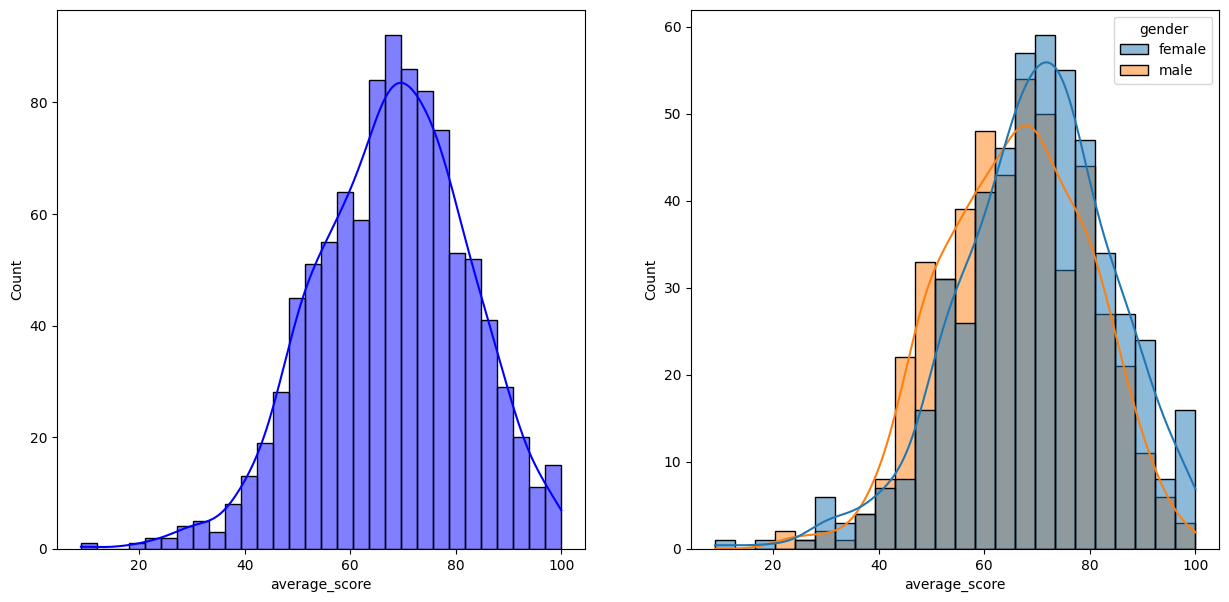

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average_score',bins=30,kde=True,color='blue')
plt.subplot(122)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.show()

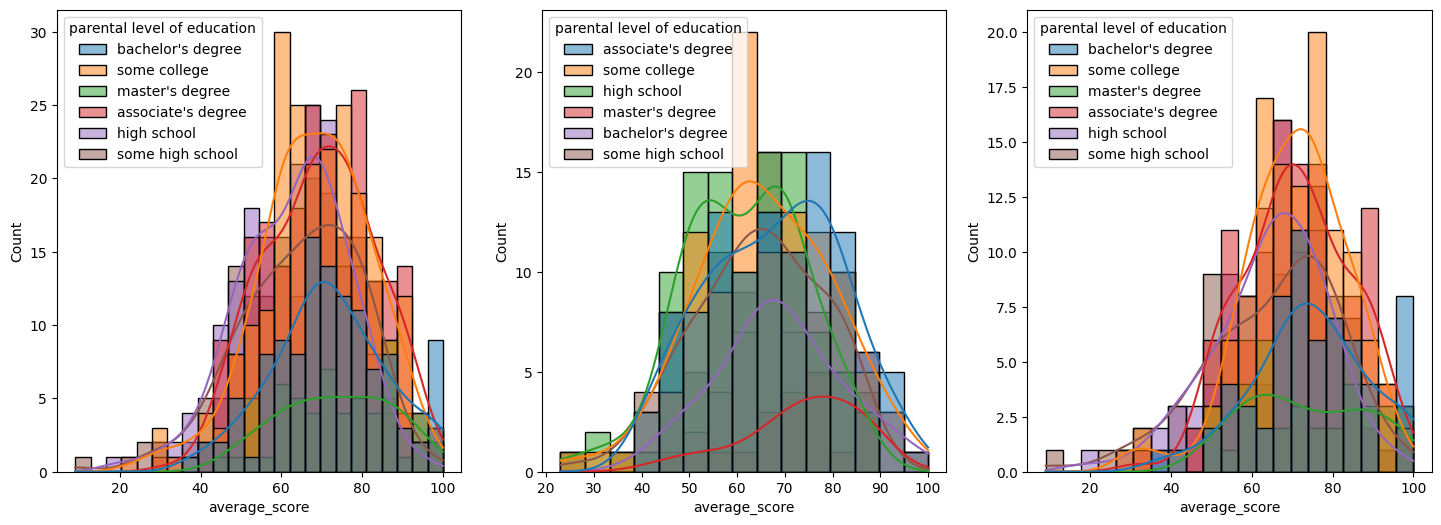

In [45]:
plt.subplots(1,3,figsize=(24,6))

plt.subplot(141)
ax =sns.histplot(data=df,x='average_score',kde=True,hue='parental level of education')

plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True,hue='parental level of education')

plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='parental level of education')

plt.show()

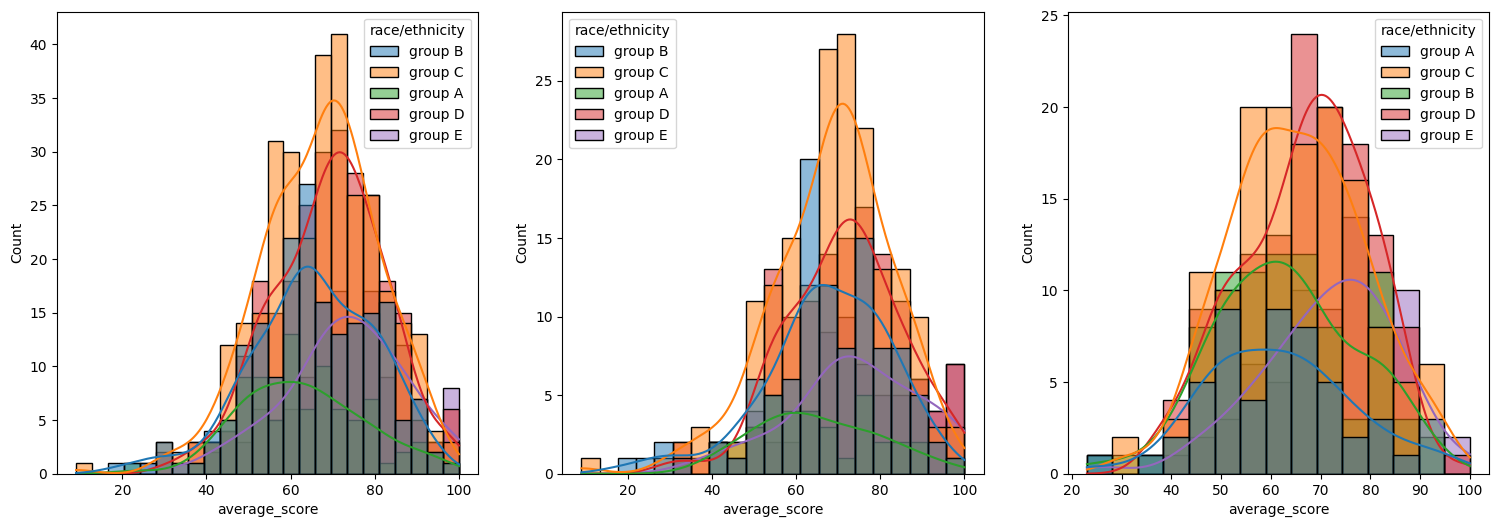

In [46]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average_score',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True,hue='race/ethnicity')
plt.show()

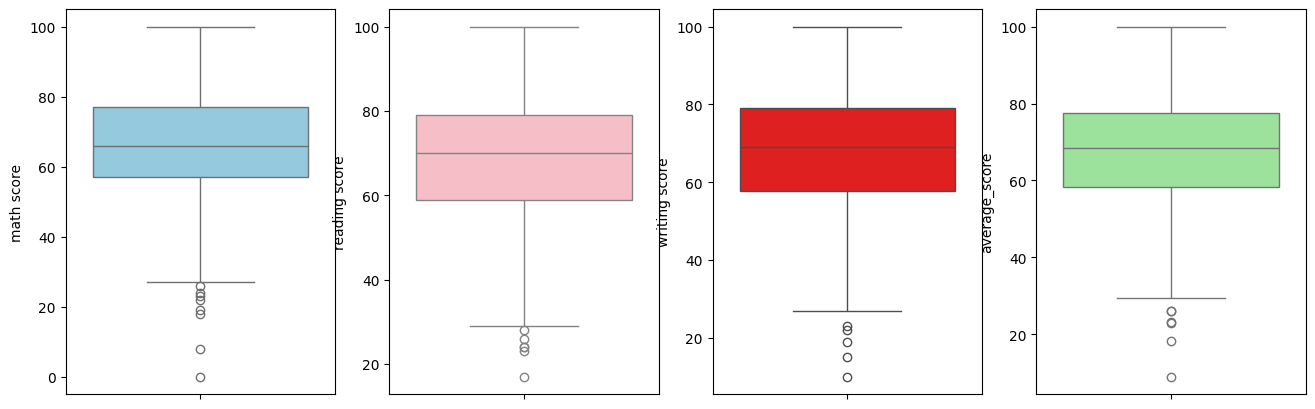

In [47]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='lightpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='red')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()


In [50]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [131]:

y=df["math score"]
X = df.drop(
    columns=[
        "math score",
        "reading score",
        "writing score",
        
    ],
    axis=1
)



In [132]:
n_features = X.select_dtypes(exclude=['O']).columns
c_features = X.select_dtypes(include=['O']).columns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
oh_transformer = OneHotEncoder()
num_transformer = StandardScaler()
preprocessor = ColumnTransformer(
[
        ('num', num_transformer, n_features),
        ('cat', oh_transformer, c_features)
    ]
)

In [133]:
x=preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



In [134]:
def evaluate_model(true, predicted):
    mse = mean_squared_error(true, predicted)
    r2 = r2_score(true, predicted)
    return mse, r2

In [141]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'GradientBoostingRegressor': GradientBoostingRegressor(),
    'XGBRegressor': XGBRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}
model_list = []
r2_list = []
for i in range (len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)


    y_train_pred = model.predict(X_train)
        
    y_test_pred = model.predict(X_test)

    model_train_mse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    print(f"Model: {list(models.keys())[i]}")
    model_list.append(list(models.keys())[i])
    print("model performance on training data: ")
    print(f"  MSE: {model_train_mse:.4f}")
    print(f"  R2: {model_train_r2:.4f}")
    print("-----------")
    print("model performance on test data: ")
    print(f"  MSE: {model_test_mse:.4f}")
    print(f"  R2: {model_test_r2:.4f}")
    print("=====================================")
    r2_list.append(model_test_r2)


Model: Linear Regression
model performance on training data: 
  MSE: 13.1254
  R2: 0.9418
-----------
model performance on test data: 
  MSE: 12.8486
  R2: 0.9472
Model: Lasso
model performance on training data: 
  MSE: 22.4492
  R2: 0.9004
-----------
model performance on test data: 
  MSE: 22.2508
  R2: 0.9086
Model: Ridge
model performance on training data: 
  MSE: 13.1352
  R2: 0.9417
-----------
model performance on test data: 
  MSE: 12.8676
  R2: 0.9471
Model: GradientBoostingRegressor
model performance on training data: 
  MSE: 10.0965
  R2: 0.9552
-----------
model performance on test data: 
  MSE: 15.2694
  R2: 0.9373
Model: XGBRegressor
model performance on training data: 
  MSE: 0.8773
  R2: 0.9961
-----------
model performance on test data: 
  MSE: 21.0617
  R2: 0.9134
Model: Decision Tree
model performance on training data: 
  MSE: 0.2062
  R2: 0.9991
-----------
model performance on test data: 
  MSE: 33.6688
  R2: 0.8616
Model: KNeighborsRegressor
model performance on t

Linear Regression gives the best results


In [142]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model', 'R2 Score']).sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
0,Linear Regression,0.947199
2,Ridge,0.947121
3,GradientBoostingRegressor,0.937250
8,Gradient Boosting,0.937182
7,Random Forest,0.921101
4,XGBRegressor,0.913447
1,Lasso,0.908560
6,KNeighborsRegressor,0.874273
5,Decision Tree,0.861638


In [145]:
select_model=LinearRegression(fit_intercept=True)
lin_model= select_model.fit(X_train,y_train)
y_pred=select_model.predict(X_test)
r2_s=r2_score(y_test,y_pred)*100
print(f"accuracy of the model is {r2_s}")


accuracy of the model is 94.719880483471


Text(0, 0.5, 'predicted')

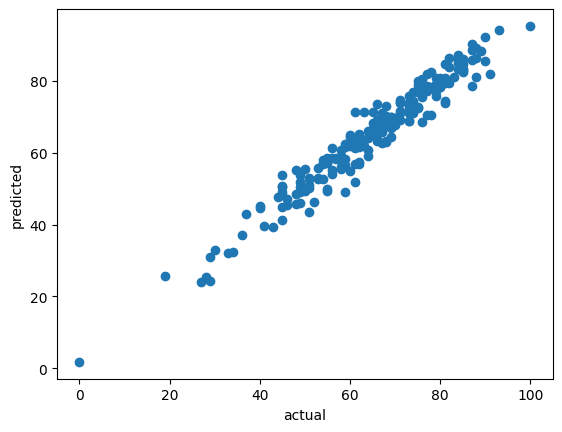

In [147]:
plt.scatter(y_test,y_pred)
plt.xlabel("actual")
plt.ylabel("predicted")

<Axes: xlabel='math score'>

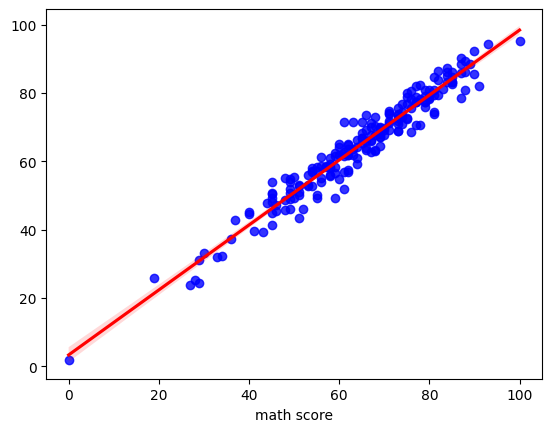

In [161]:
sns.regplot(x=y_test,y=y_pred, scatter_kws={"color": "blue"}, line_kws={"color": "red"})

In [164]:
pred_df=pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'difference': y_test - y_pred})
pred_df.head(10)

,Actual,Predicted,difference
521,91,81.906250,9.093750
737,53,55.843750,-2.843750
740,80,78.187500,1.812500
660,74,76.812500,-2.812500
411,84,87.250000,-3.250000
678,81,79.421875,1.578125
626,69,67.109375,1.890625
513,54,52.718750,1.281250
859,87,78.609375,8.390625
136,51,51.031250,-0.031250
